**Please remember that the first step is to make a copy of this notebook, and then share that notebook with me. Detailed steps on how to share the notebook are available in the presentation from December 9.**

# Rules

The data in this project are provided by Citi for our use in this project. You are not permitted to share it beyond this course.

You are not allowed to discuss the project with anyone other than the instructor.

You are allowed to access any resources (other than communicating with other people), including the course notes, recordings, and other online materials. Cite resources used as appropriate.

If something is not specified in the instructions, then you are to take the steps that you believe are the most appropriate. For example, if I don't tell you which clustering algorithm to use, you are to choose which one to use.

At all times you will be assessed, in part, in the clarity of your presentation including your writing and any visualization that you provide.

Everything you do must be contained within this notebook. You will not be submitting a pdf version. I will grade the notebook directly.

The number of points for each portion is shown in bold, e.g., **(10)**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

The following will read in the data for the project.

In [ ]:
fulldata = pd.read_csv("http://www.stat.cmu.edu/~cschafer/MSCF/FinalProjectData.csv")
fulldata.head()

,spoof,price_level,side,size,L1BidVolume,L1AskVolume,L2BidVolume,L2AskVolume,L3BidVolume,L3AskVolume,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9
0,1,1,1,0,0,0,0,2,1,1,0.285473,0.307095,-0.162560,0.571682,-0.927855,0.266910,0.419302,0.375334,0.197479,0.440146
1,1,1,1,0,3,0,3,0,1,3,0.171987,0.148828,-0.126636,0.707624,-1.028241,0.327790,0.392594,0.498095,0.144682,0.580797
2,0,4,1,0,1,2,1,1,2,0,1.136343,1.354168,0.555337,-0.691090,0.982827,-0.859628,-0.333628,-0.713966,0.909916,-0.609235
3,0,1,0,0,0,0,0,0,1,1,0.165092,0.168728,-0.023689,0.548146,-0.729518,-0.071050,0.268721,0.567562,0.063072,0.553360
4,0,4,1,0,1,0,1,2,1,1,1.135701,1.284084,0.312814,-0.561310,0.310497,-0.092963,-0.029125,-0.562302,0.804659,-0.537767


# Variable Explanations

In what follows, I will be making reference to three types of variables. 

First, there is the **response**:

1.   `spoof`: a value of 1 indicates a case of spoofing

Second, there are the **original features**:

2.   `price_level`: Price level in the book of this transaction. See the overview presentation for an illustration.
3. `side`: 0 indicates a buy, 1 indicates a sell
4. `size`: The size of the order.
5. `LxBidVolume`: Volume in book at level x on the bid side. See the overview presentation for an illustration.
6. `LxAskVolume`: Volume in book at level x on the ask side. See the overview presentation for an illustration.

Third, there are the **derived features**:
7. `X0` thru `X9`: The features derived from the neural network.

Note that the size and volume variables have been binned, and take values from 0 to 4. 0 indicates smaller number of shares, while 4 is highest number of shares. These measures are taken relative to typical trade volumes for the stock.




# Big Picture

To start, make sure you have watched the introductory presentation that I made in lecture on December 9. It provides important background on the problem.

This project is about exploring the relationships between the derived features and the original features, and explaining to someone how the original features are being used to make the classifications. In other words, we are trying to cut through, to the extent possible, the "black box" nature of neural networks.

Please remember that I am **not** asking you to give a tutorial on neural networks. The point is **not** to describe how neural networks produce classifications from inputs. This exercise requires zero knowledge of how neural networks function. For each step you take, ask yourself: "Does doing this require knowledge of how a neural network functions?" If the answer is "Yes" then you are going in a wrong direction.


# Part 1: Exploratory Questions

## Task 1

Run the code below. Comment on the output in the text box below. **(5)**

1. All derived features have a clear bimodal distribution except maybe X5 which is not as clear
1. All derived features are highly correlated to each other except X4 and X5
1. There is a clear nonlinear relationship in some pairs, for example (X0, X2) and (X0, X8)
1. X1 and X9 give almost the same information, although they are negatively correlated


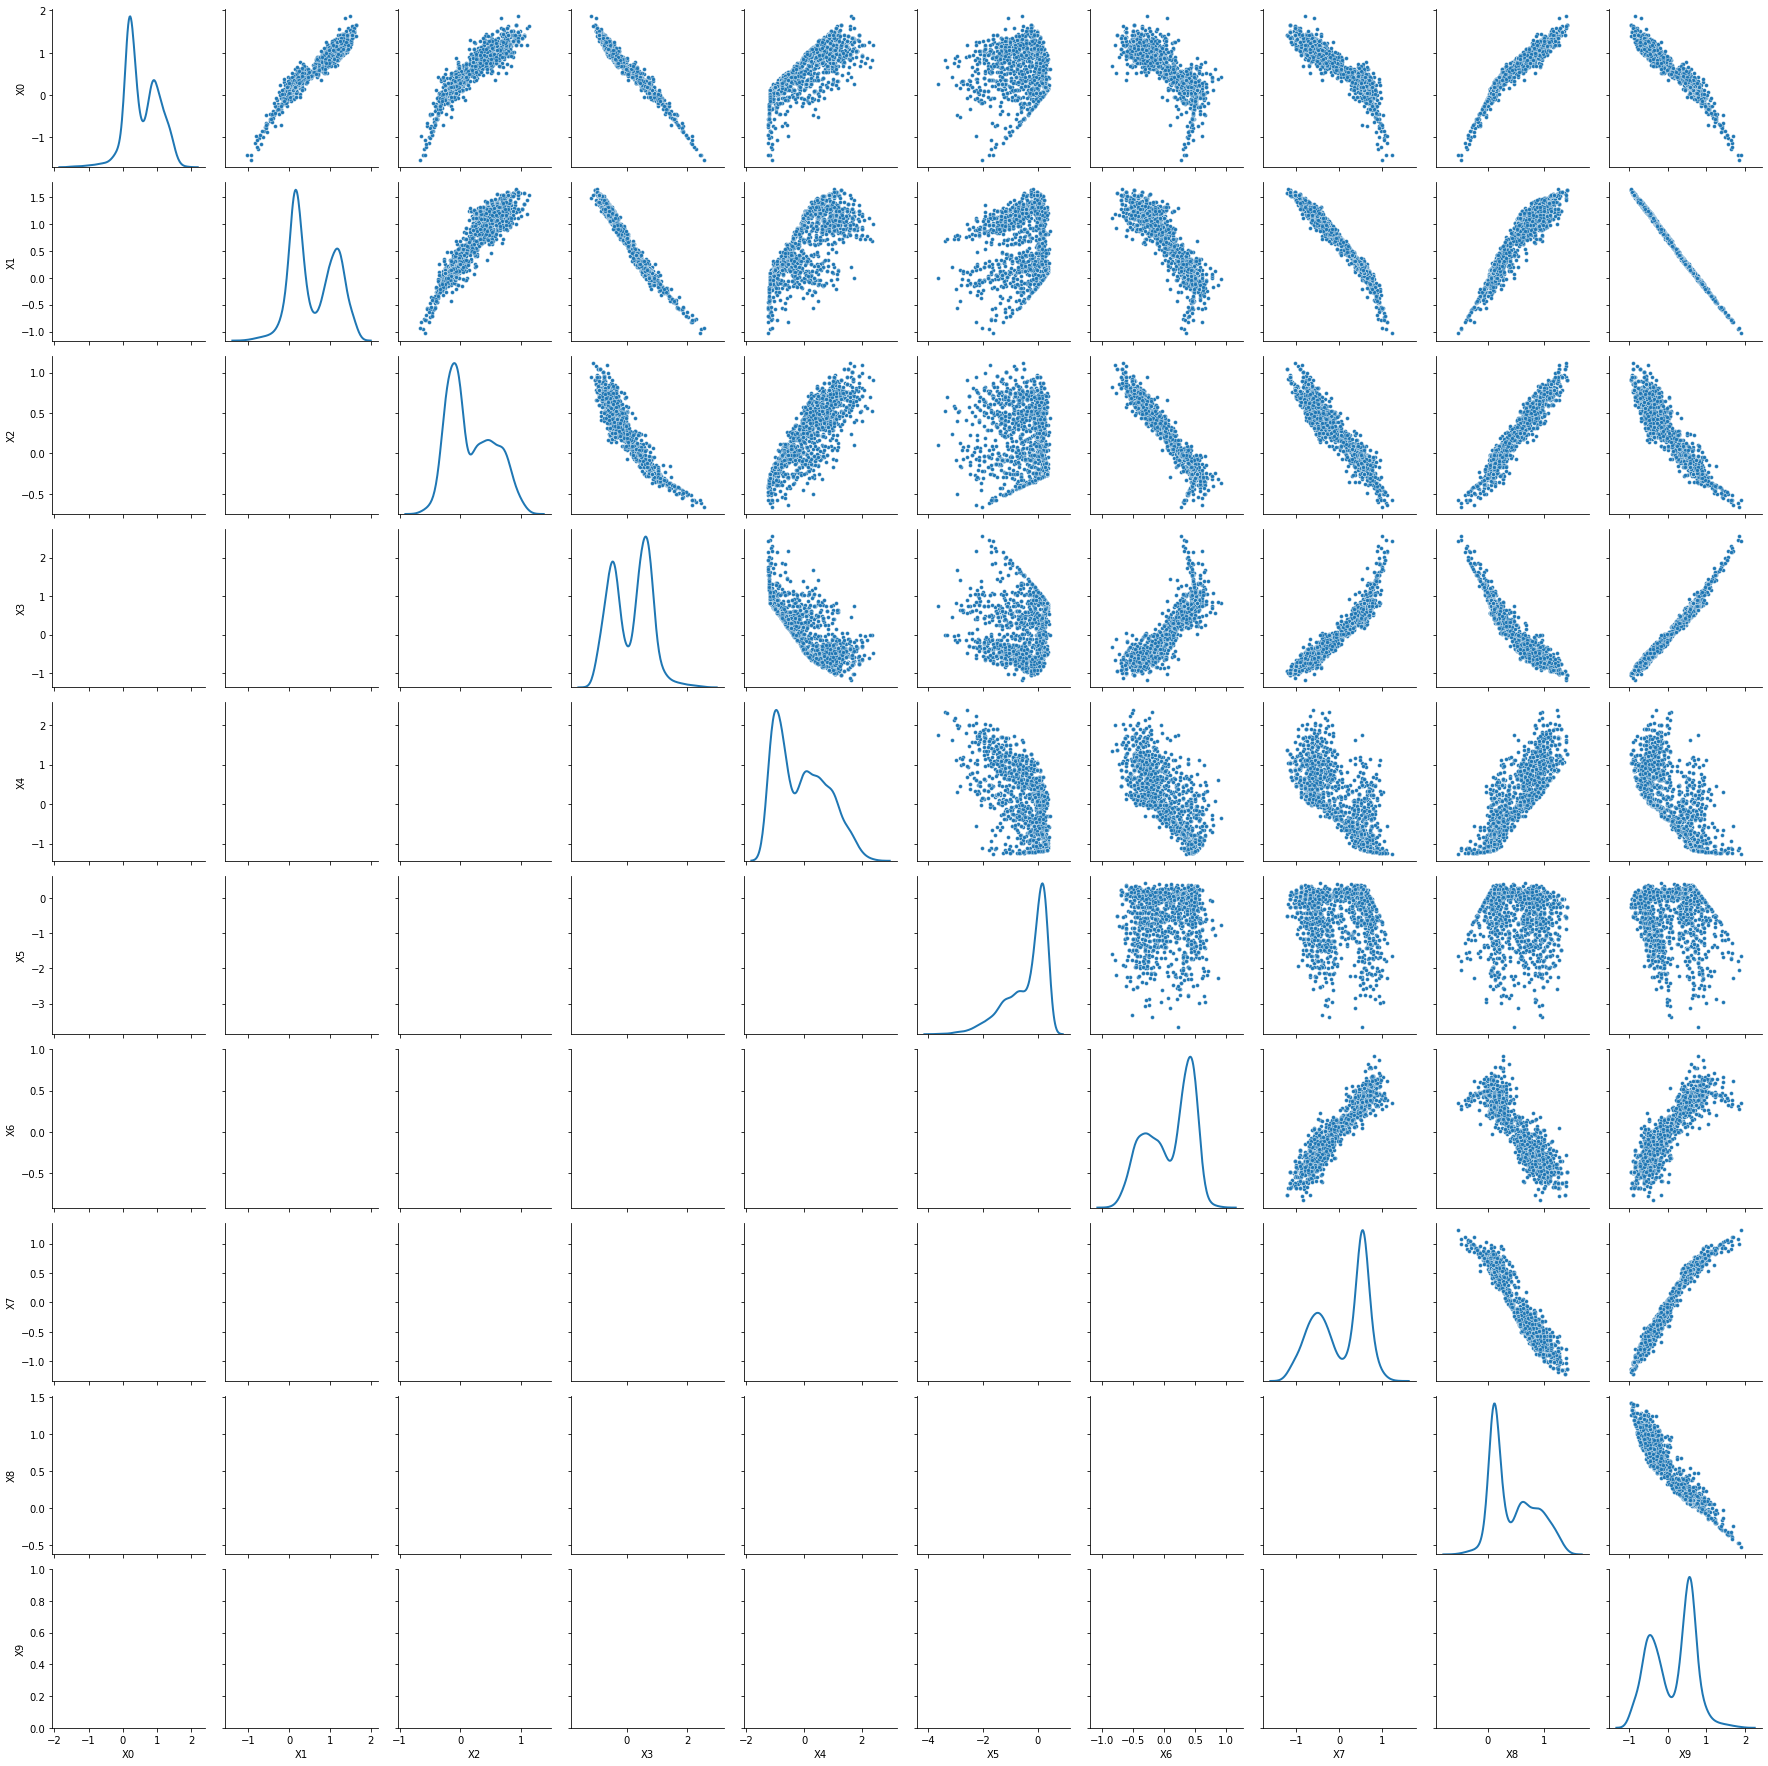

In [ ]:
derivedfeatures = fulldata.iloc[:,10:20]

g = sns.PairGrid(derivedfeatures, diag_sharey=False)
g.map_upper(sns.scatterplot, s=15)
g.map_diag(sns.kdeplot, lw=2)

## Task 2

Run PCA on the **derived features**. Add columns to the data frame based on this analysis. Do not add more dimensions than you believe are necessary, and justify your choices. **(10)**

Below are the scree plot and a plot of the first 3 principal components. The PCA is performed on the standardized data. 

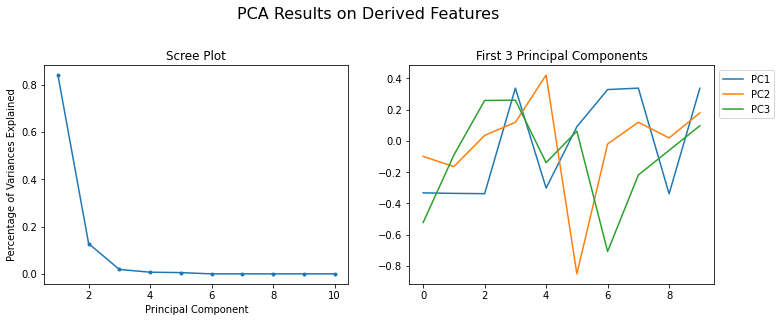

In [ ]:
from pandas import Series, DataFrame
from sklearn.decomposition import PCA

derivedfeatures = (derivedfeatures - derivedfeatures.mean())/derivedfeatures.std()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

n_components=10
pcaout = PCA(n_components=n_components).fit(derivedfeatures)
Series(pcaout.explained_variance_ratio_, index=range(1, n_components+1)).plot(style='.-', ax=ax[0])
DataFrame(pcaout.components_[:3].T, columns=['PC1', 'PC2', 'PC3']).plot(ax=ax[1], legend=None)

ax[0].set(title='Scree Plot', ylabel='Percentage of Variances Explained', xlabel='Principal Component')
ax[1].set(title='First 3 Principal Components')

plt.suptitle('PCA Results on Derived Features', fontsize=16)
plt.subplots_adjust(top=0.8)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

The cumulative percentage of variance explained is printed out, which shows that the first 2 components together explain almost 97% of the variances in the 
data. The additional variance explained beyond PC2 is small, so we will only add to the data the PC scores corresponding to the first 2 PCs. 

In [ ]:
pcaout.explained_variance_ratio_.cumsum()

array([0.84124414, 0.96913339, 0.98773746, 0.99479262, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [ ]:
score1, score2 = pcaout.transform(derivedfeatures)[:, :2].T

fulldata['Score1'] = score1
fulldata['Score2'] = score2
fulldata.head()

,spoof,price_level,side,size,L1BidVolume,L1AskVolume,L2BidVolume,L2AskVolume,L3BidVolume,L3AskVolume,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Score1,Score2
0,1,1,1,0,0,0,0,2,1,1,0.285473,0.307095,-0.162560,0.571682,-0.927855,0.266910,0.419302,0.375334,0.197479,0.440146,2.138840,-0.838629
1,1,1,1,0,3,0,3,0,1,3,0.171987,0.148828,-0.126636,0.707624,-1.028241,0.327790,0.392594,0.498095,0.144682,0.580797,2.572476,-0.788925
2,0,4,1,0,1,2,1,1,2,0,1.136343,1.354168,0.555337,-0.691090,0.982827,-0.859628,-0.333628,-0.713966,0.909916,-0.609235,-3.736184,0.247634
3,0,1,0,0,0,0,0,0,1,1,0.165092,0.168728,-0.023689,0.548146,-0.729518,-0.071050,0.268721,0.567562,0.063072,0.553360,2.220471,-0.197965
4,0,4,1,0,1,0,1,2,1,1,1.135701,1.284084,0.312814,-0.561310,0.310497,-0.092963,-0.029125,-0.562302,0.804659,-0.537767,-2.587700,-0.910673


## Task 3

Run a nonlinear dimension reduction approach on the derived features. Add columns to the data frame based on this analysis. Visualize the results, and comment on structure that you may see. **(10)**

Based on the PCA results, we project the derived features to a 2D plane. We have tried both Isomap and the diffusion map algorithm. As a result, the diffusion map does not seem to reveal useful information, while the projection by Isomap is very similar to that of PCA. 

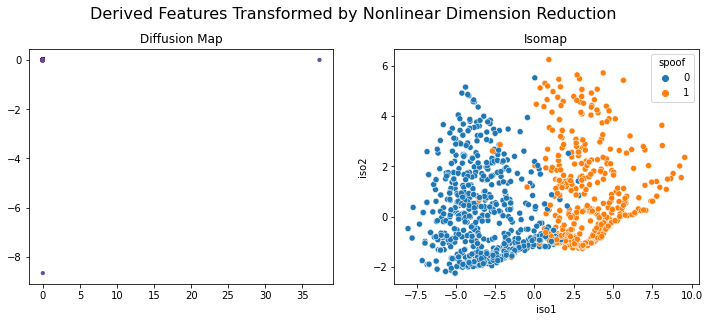

In [ ]:
from pydiffmap import diffusion_map as dm
from sklearn import manifold

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

np.random.seed(0)
dmap = dm.DiffusionMap.from_sklearn(n_evecs=2, epsilon="bgh").fit_transform(derivedfeatures)
iso = manifold.Isomap(n_neighbors=10, n_components=2).fit_transform(derivedfeatures)

ax1.scatter(dmap[:, 0], dmap[:, 1], c=fulldata['spoof'], cmap=plt.cm.Spectral, s=10)
ax1.set(title='Diffusion Map')

sns.scatterplot(x='iso1', y='iso2', hue='spoof', data=DataFrame({'spoof': fulldata['spoof'], 'iso1': iso[:, 0], 'iso2': iso[:, 1]}), ax=ax2)
ax2.set(title='Isomap')

plt.suptitle('Derived Features Transformed by Nonlinear Dimension Reduction', fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

Now we add the Isomap transformed data to the data frame. 

In [ ]:
fulldata['iso1'] = iso[:, 0]
fulldata['iso2'] = iso[:, 1]
fulldata.head()

,spoof,price_level,side,size,L1BidVolume,L1AskVolume,L2BidVolume,L2AskVolume,L3BidVolume,L3AskVolume,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Score1,Score2,iso1,iso2
0,1,1,1,0,0,0,0,2,1,1,0.285473,0.307095,-0.162560,0.571682,-0.927855,0.266910,0.419302,0.375334,0.197479,0.440146,2.138840,-0.838629,2.652201,-1.067184
1,1,1,1,0,3,0,3,0,1,3,0.171987,0.148828,-0.126636,0.707624,-1.028241,0.327790,0.392594,0.498095,0.144682,0.580797,2.572476,-0.788925,3.050153,-1.172104
2,0,4,1,0,1,2,1,1,2,0,1.136343,1.354168,0.555337,-0.691090,0.982827,-0.859628,-0.333628,-0.713966,0.909916,-0.609235,-3.736184,0.247634,-4.783878,0.452232
3,0,1,0,0,0,0,0,0,1,1,0.165092,0.168728,-0.023689,0.548146,-0.729518,-0.071050,0.268721,0.567562,0.063072,0.553360,2.220471,-0.197965,3.628432,0.195379
4,0,4,1,0,1,0,1,2,1,1,1.135701,1.284084,0.312814,-0.561310,0.310497,-0.092963,-0.029125,-0.562302,0.804659,-0.537767,-2.587700,-0.910673,-3.169145,-1.519548


## Task 4

Cluster the obsevations based on the derived features (or one of the lower-dimensional representations derived above). Add the cluster labels to the data frame. **(10)**

We have seen that Isomap and PCA give very similar results. Since PCA is computationally cheaper, we will continue our analysis on the PCA results. 

We apply $k$-means clustering on ```Score1``` and ```Score2``` and add the resulting label to a new column ```cluster```.

In [ ]:
from sklearn.cluster import KMeans

X = fulldata[['Score1', 'Score2']]
np.random.seed(0)
kmout = KMeans(n_clusters=2, n_init=10).fit(X)
fulldata['cluster'] = 1 - kmout.predict(X)

fulldata.head()

,spoof,price_level,side,size,L1BidVolume,L1AskVolume,L2BidVolume,L2AskVolume,L3BidVolume,L3AskVolume,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Score1,Score2,iso1,iso2,cluster
0,1,1,1,0,0,0,0,2,1,1,0.285473,0.307095,-0.162560,0.571682,-0.927855,0.266910,0.419302,0.375334,0.197479,0.440146,2.138840,-0.838629,2.652201,-1.067184,1
1,1,1,1,0,3,0,3,0,1,3,0.171987,0.148828,-0.126636,0.707624,-1.028241,0.327790,0.392594,0.498095,0.144682,0.580797,2.572476,-0.788925,3.050153,-1.172104,1
2,0,4,1,0,1,2,1,1,2,0,1.136343,1.354168,0.555337,-0.691090,0.982827,-0.859628,-0.333628,-0.713966,0.909916,-0.609235,-3.736184,0.247634,-4.783878,0.452232,0
3,0,1,0,0,0,0,0,0,1,1,0.165092,0.168728,-0.023689,0.548146,-0.729518,-0.071050,0.268721,0.567562,0.063072,0.553360,2.220471,-0.197965,3.628432,0.195379,1
4,0,4,1,0,1,0,1,2,1,1,1.135701,1.284084,0.312814,-0.561310,0.310497,-0.092963,-0.029125,-0.562302,0.804659,-0.537767,-2.587700,-0.910673,-3.169145,-1.519548,0


## Task 5

How are the cluster labels you found in Task 4 related to the response? **(5)**

Below are scatter plots of the PC scores colored by clusters and the response, respectively. The similarity indicates that the cluster label is a good prediction for spoofing. 

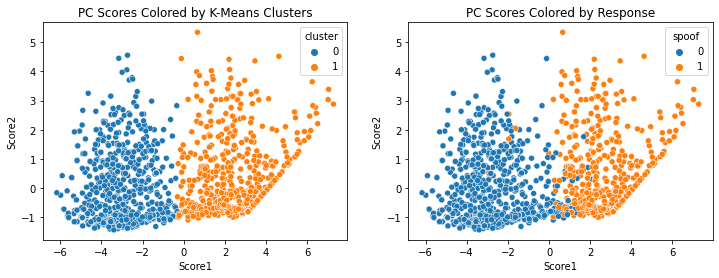

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x='Score1', y='Score2', data=fulldata, hue='cluster', ax=ax1)
ax1.set(title='PC Scores Colored by K-Means Clusters')

sns.scatterplot(x='Score1', y='Score2', data=fulldata, hue='spoof', ax=ax2)
ax2.set(title='PC Scores Colored by Response')

plt.show()

Below is a summary of the cluster label as a predition. The precision is 91.5% and the recall is 98.5%. 

In [ ]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(fulldata['spoof'], fulldata['cluster'])
DataFrame(confusion, columns=['Guess 0', 'Guess 1'], index=['True 0', 'True 1'])

,Guess 0,Guess 1
True 0,873,95
True 1,15,1027


In [ ]:
tn, fp, fn, tp = confusion.ravel()
tp/(tp + fp), tp/(tp + fn)

(0.9153297682709447, 0.9856046065259118)

In addition, the cluster centers are both close to the horizontal line $y=0$. This means the boundary separating the two clusters is close to vertical and ```Score1``` alone is enough to predict cluster (and hence spoofing).

In [ ]:
kmout.cluster_centers_

array([[ 2.36081734, -0.01073682],
       [-2.98292461,  0.01356612]])

The above clustering is run on the PC scores. If we do the same on the Isomap transformed data, the decision boundary will be close to vertical too. Below are the cluster centers for Isomap results. 

In [ ]:
KMeans(n_clusters=2, n_init=10).fit(fulldata[['iso1', 'iso2']]).cluster_centers_

array([[-3.67129310e+00,  2.68240347e-03],
       [ 2.98271874e+00, -2.17930165e-03]])

## Task 6

How are the cluster labels you found in Task 4 to the observed features? **(10)**

We have established that the cluster label is closely related to ```spoof```, whose relationship with the order book status (the variables```L1BidVolume```, ```L2BidVolume``` and so forth) will be explored in Task 7. Here we only look at the relationship between the cluster label and ```price_level```, ```side``` and ```size``` variables. 

First we separate the data by ```side```. For buy and sell orders we show scatter plots of ```price_level``` against ```size``` separately. The scatter plots are colored by cluster labels. Since the values are discrete, for visualization we add small noise to the data. This is called jittering. 

The result is pretty clear given the visualization. Observations with small size which are at a higher price level tend to be of cluster 0. Observations that do not fit this criterion are of cluster 1. We see this same pattern in both buy and sell orders. 

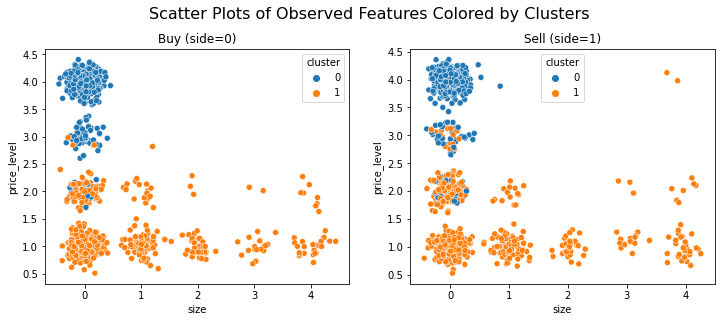

In [ ]:
from scipy.stats import norm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

side0 = fulldata[fulldata['side']==0][['price_level', 'size', 'cluster']]
side0[['price_level', 'size']] += norm.rvs(size=len(side0)*2, scale=0.15).reshape((len(side0), 2))

side1 = fulldata[fulldata['side']==1][['price_level', 'size', 'cluster']]
side1[['price_level', 'size']] += norm.rvs(size=len(side1)*2, scale=0.15).reshape((len(side1), 2))

sns.scatterplot(x='size', y='price_level', data=side0, hue='cluster', ax=ax1)
sns.scatterplot(x='size', y='price_level', data=side1, hue='cluster', ax=ax2)
ax1.set(title='Buy (side=0)')
ax2.set(title='Sell (side=1)')

plt.suptitle('Scatter Plots of Observed Features Colored by Clusters', fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

## Task 7

The current status of the order book is captured by the six observed variables `L1AskVolume`, `L1BidVolume`, and so forth.

It makes sense to ask if a low-dimensional representation of this information would preserve important information.

Take an appropriate approach to create a one-dimensional representation of the current status of the order book. **(10)**

We run PCA, Isomap and the diffusion map on the order book status data. 

Now we want to determine which one is a better approach for spoof prediction. First we look at the scatter plots of the transformed data and the corresponding ```spoof``` values. Although only vaguely, for each method we see a pattern that the transformed data goes monitonically with the probability of being spoofing. We flip the PCA and Isomap results so that they all go up with the probability. This behavior makes it possible to treat the transformed data as a score for spoofing prediction. 

In [ ]:
book = fulldata[['L3BidVolume', 'L2BidVolume', 'L1BidVolume', 'L1AskVolume', 'L2AskVolume', 'L3AskVolume']]
dmap = dm.DiffusionMap.from_sklearn(n_evecs=1, epsilon="bgh").fit_transform(book).flatten()
pca = -PCA(n_components=1).fit_transform(book).flatten()
iso = -manifold.Isomap(n_neighbors=10, n_components=1).fit_transform(book).flatten()

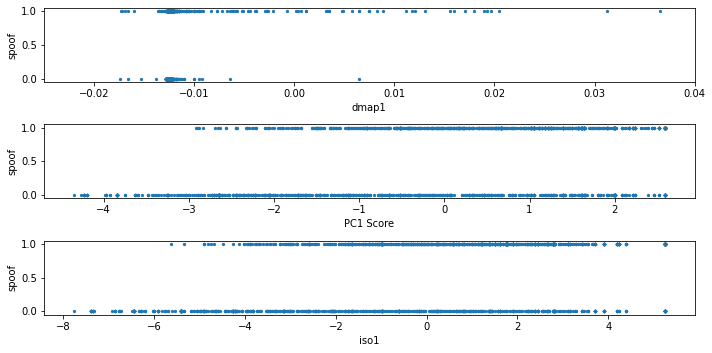

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 5))

DataFrame({'dmap1': dmap, 'spoof': fulldata['spoof']}).plot('dmap1', 'spoof', kind='scatter', legend=None, s=5, ax=ax1)
DataFrame({'PC1 Score': pca, 'spoof': fulldata['spoof']}).plot('PC1 Score', 'spoof', kind='scatter', legend=None, s=5, ax=ax2)
DataFrame({'iso1': iso, 'spoof': fulldata['spoof']}).plot('iso1', 'spoof', kind='scatter', legend=None, s=5, ax=ax3)
ax1.set(xlim=(-0.025, 0.04))
plt.tight_layout()
plt.show()

Next we present the ROC curves for all 3 methods. None of them is significantly better than others as a predictor. Again we will go with PCA. 

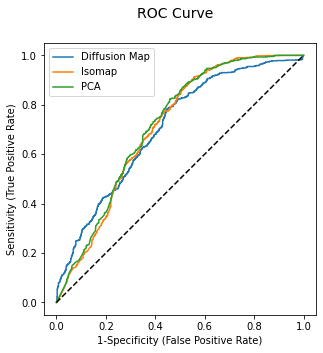

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
fig.suptitle('ROC Curve', fontsize=14)

fpr, tpr, _ = roc_curve(fulldata['spoof'], dmap)
ax.plot(fpr, tpr, label='Diffusion Map')

fpr, tpr, _ = roc_curve(fulldata['spoof'], iso)
ax.plot(fpr, tpr, label='Isomap')

fpr, tpr, _ = roc_curve(fulldata['spoof'], pca)
ax.plot(fpr, tpr, label='PCA')

ax.plot([0, 1], [0, 1], 'k--')
ax.set( aspect=1, 
        xlabel='1-Specificity (False Positive Rate)', 
        ylabel='Sensitivity (True Positive Rate)')

plt.legend()
plt.show()

The below scatter plot shows that the transformed data by Isomap and PCA are highly correlated so using either as a representation of the order book will not make much difference. 

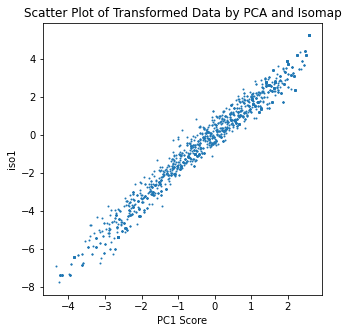

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.scatter(pca, iso, s=1)
ax.set(xlabel='PC1 Score', ylabel='iso1', 
       title='Scatter Plot of Transformed Data by PCA and Isomap')
plt.show()

Finally we add the PC scores to the data as a new column ```OrderBookScore1```. 

In [ ]:
fulldata['OrderBookScore1'] = pca
fulldata.head()

,spoof,price_level,side,size,L1BidVolume,L1AskVolume,L2BidVolume,L2AskVolume,L3BidVolume,L3AskVolume,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Score1,Score2,iso1,iso2,cluster,OrderBookScore1
0,1,1,1,0,0,0,0,2,1,1,0.285473,0.307095,-0.162560,0.571682,-0.927855,0.266910,0.419302,0.375334,0.197479,0.440146,2.138840,-0.838629,2.652201,-1.067184,1,0.633862
1,1,1,1,0,3,0,3,0,1,3,0.171987,0.148828,-0.126636,0.707624,-1.028241,0.327790,0.392594,0.498095,0.144682,0.580797,2.572476,-0.788925,3.050153,-1.172104,1,-1.081077
2,0,4,1,0,1,2,1,1,2,0,1.136343,1.354168,0.555337,-0.691090,0.982827,-0.859628,-0.333628,-0.713966,0.909916,-0.609235,-3.736184,0.247634,-4.783878,0.452232,0,0.353404
3,0,1,0,0,0,0,0,0,1,1,0.165092,0.168728,-0.023689,0.548146,-0.729518,-0.071050,0.268721,0.567562,0.063072,0.553360,2.220471,-0.197965,3.628432,0.195379,1,1.397228
4,0,4,1,0,1,0,1,2,1,1,1.135701,1.284084,0.312814,-0.561310,0.310497,-0.092963,-0.029125,-0.562302,0.804659,-0.537767,-2.587700,-0.910673,-3.169145,-1.519548,0,0.210195


## Task 8

Explore the relationship, if any, between the one-dimensional representation of the order book you found in Task 7 and the derived features (or the representations you found of the derived features). Use appropriate smoothing methods in your visualizations. (For example, if your one-dimensional representation of the order book is continuous, you could plot that versus `X0`, but put a nonparametric smooth on that plot.) **(5)**

We inspect the relationship between ```OrderBookScore1```, the one dimensional representation of the order book, and ```Score1```, the PC1 score of the derived features. A scatter plot and a nonparametric smooth fit is presented below. Roughly speaking, ```Score1``` increases as ```OrderBookScore1```. 


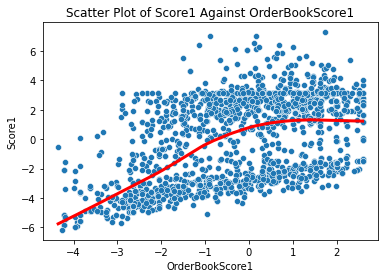

In [ ]:
import statsmodels.api as sm

lowout = sm.nonparametric.lowess(fulldata['Score1'], fulldata['OrderBookScore1'], frac=0.5)

ax = sns.scatterplot(x='OrderBookScore1', y='Score1', data=fulldata)
DataFrame(lowout, columns=['OrderBookScore1', 'smooth']).set_index('OrderBookScore1').plot(ax=ax, legend=None, style='r', linewidth=3)
ax.set(title='Scatter Plot of Score1 Against OrderBookScore1')
plt.show()

Below we present the same scatter plot without the nonparametric smooth. There seems to be a two-cluster structure and in each cluster there is a linear relationship. On the right we show yet another scatter plot that is colored by ```spoof```. Based on this result, one can fit a linear regression in spoofing and nonspoofing cases separately, which can then be used to build a mixture model conditioned on ```OrderBookScore1``` for spoofing prediction. 

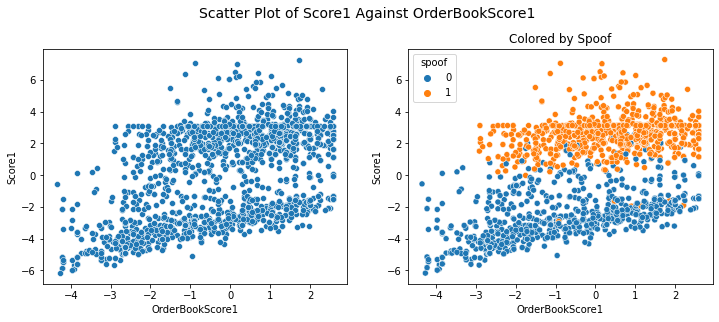

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(x='OrderBookScore1', y='Score1', data=fulldata, ax=ax1)
sns.scatterplot(x='OrderBookScore1', y='Score1', hue='spoof', data=fulldata, ax=ax2)
ax2.set(title='Colored by Spoof')

plt.suptitle('Scatter Plot of Score1 Against OrderBookScore1', fontsize=14)
plt.subplots_adjust(top=0.85)
plt.show()

# Part 2: Getting at the Relationships

Now for the big question: What can you say about the relationship between the derived features and the observed features?

I will start you with a suggestion: Inspect the relationship between the first principal component from Task 2 and the variable `size`. The variable `size` has a clear relationship with the response (verify this). Hence, a clear statement can be made about how the first principal component is taking advantage of size to achieve better classifications.

You should start with the above example, but you should then demonstrate **two additional relationships** that you find among the variables. Again, remember that the goal is to be able to describe how the derived variables are using the observed variables to reach the classifications.

This part is worth a total of 30 points. You will be assessed on 

1.   The **appropriateness of the methods** used to find and present the relationship. This includes appropriate choice of visualizations. **(20)**
2. The **clarity of the written explanations** of the results. Be clear, not necessarily wordy. **(10)**
3. The **clarity of the visualizations**. Label your axes appropriately, etc. **(5)**

In addition, I reserve the right to penalize you for not exploring a variety of relationships. (For example, the derived features are strongly correlated. Don't repeat the same thing three times using three different derived features.)


We will present 5 relationships: 

1. ```Score1``` v. ```size```
1. ```Score1``` v. ```price_level```
1. ```Score1``` v. ```OrderBookScore1``` and ```price_level```
1. ```Score2``` v. ```OrderBookScore2```
1. ```Score1``` and ```Score2``` v. ```side```

where we recall that ```Score1``` and ```Score2``` are PC scores from the first 2 PCs of the derived features from Task 2 and ```OrderBookScore1``` is the PC scores (from PC1) of the order book status we obtained in Task 7, and ```OrderBookScore2``` is the PC scores from PC2 of the order book status we will soon construct. 


### **```Score1``` v. ```size``` and ```Score1``` v. ```price_level```**

Below we present scatter plots of ```Score1``` against ```size``` and ```price_level```, both colored by the response. We also fit a nonparametric smooth to both. It is clear that ```Score1``` increases as ```size``` but decreases as ```price_level```, and spoofing orders tend to have larger size and tend to be at lower price levels. This is consistent with our observations in Task 5 and 6. The neural network is utilizing ```size``` and ```price_level``` to generate derived features for spoofing prediction. 

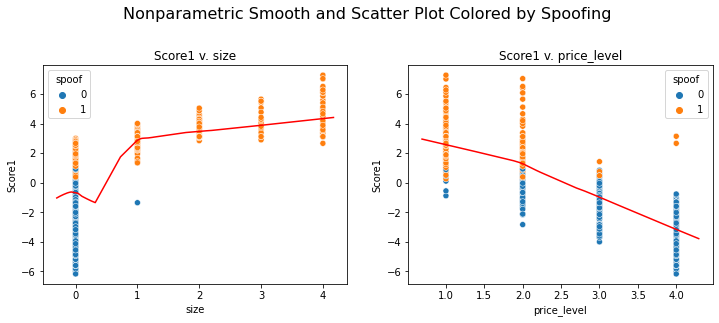

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

np.random.seed(0)
lowout = sm.nonparametric.lowess(endog=fulldata['Score1'], exog=fulldata['size'] + norm.rvs(scale=0.1, size=2010), frac=0.6)
DataFrame(lowout, columns=['size', '']).set_index('size').plot(ax=ax1, style='r', legend=None)
sns.scatterplot(y='Score1', x='size', data=fulldata, ax=ax1, hue='spoof')

lowout = sm.nonparametric.lowess(endog=fulldata['Score1'], exog=fulldata['price_level'] + norm.rvs(scale=0.1, size=2010), frac=0.6)
DataFrame(lowout, columns=['price_level', '']).set_index('price_level').plot(ax=ax2, style='r', legend=None)
sns.scatterplot(y='Score1', x='price_level', data=fulldata, ax=ax2, hue='spoof')

ax1.set(title='Score1 v. size')
ax2.set(title='Score1 v. price_level')
plt.suptitle('Nonparametric Smooth and Scatter Plot Colored by Spoofing', fontsize=16)
plt.subplots_adjust(top=0.8)
plt.show()

### **```Scores``` v. ```OrderBookScores```**

This is an extension of Task 7 and 8. Again we perform PCA on the status of the order book, but this time we consider more components. From the below table we see that the first 3 PCs together cover close to 80% of the variances. So we add the PC scores corresonding to PC2 and PC3 to the data. 

In [ ]:
book = fulldata[['L3BidVolume', 'L2BidVolume', 'L1BidVolume', 'L1AskVolume', 'L2AskVolume', 'L3AskVolume']]

pcaout = PCA(n_components=6).fit(book)
DataFrame([(i+1, pctg) for i, pctg in enumerate(pcaout.explained_variance_ratio_.cumsum())], columns=['Number of PCs', 'Cumulative Percentage of Variance Explained']).set_index('Number of PCs')


,Cumulative Percentage of Variance Explained
Number of PCs,
1,0.519186
2,0.666316
3,0.794429
4,0.871774
5,0.945551
6,1.000000


In [ ]:
scores = pcaout.transform(book)
fulldata['OrderBookScore2'] = scores[:, 1]
fulldata['OrderBookScore3'] = scores[:, 2]

Below are scatter plots of ```Score```'s against ```OrderBookScore```'s. We color the plots both by price level and by spoofing. We see interesting patterns on the top-left and bottom-middle plots, which we will take a closer look later. 

We also see that in general scatter plots involving ```Score1``` seem to have a two-cluster structure. We have seen the top-left in Task 8.

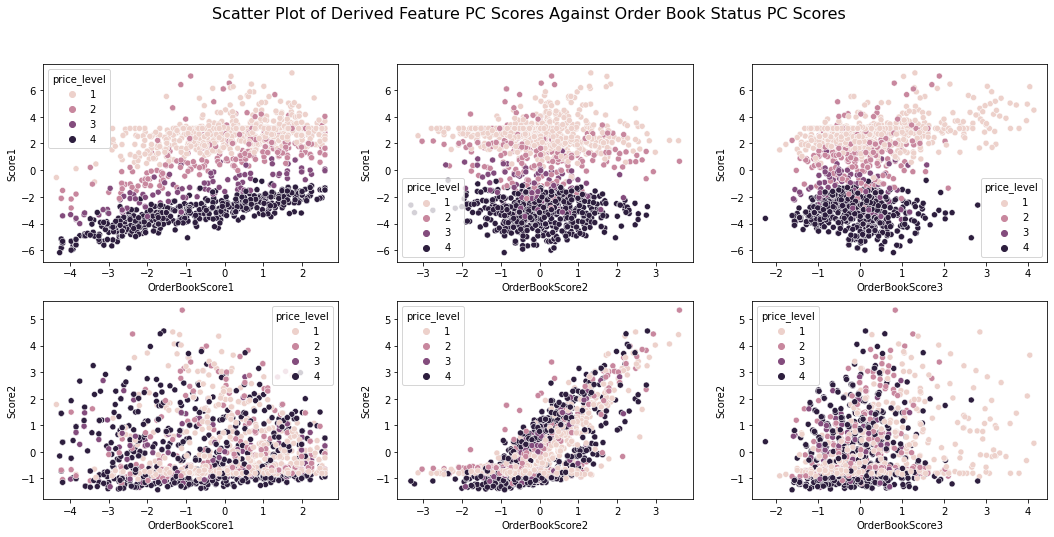

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(18, 8))
for i in range(2):
  for j in range(3):
    sns.scatterplot(y='Score%s'%(i+1), x='OrderBookScore%s'%(j+1), data=fulldata, ax=ax[i][j], hue='price_level')

plt.suptitle('Scatter Plot of Derived Feature PC Scores Against Order Book Status PC Scores', fontsize=16)
plt.show()

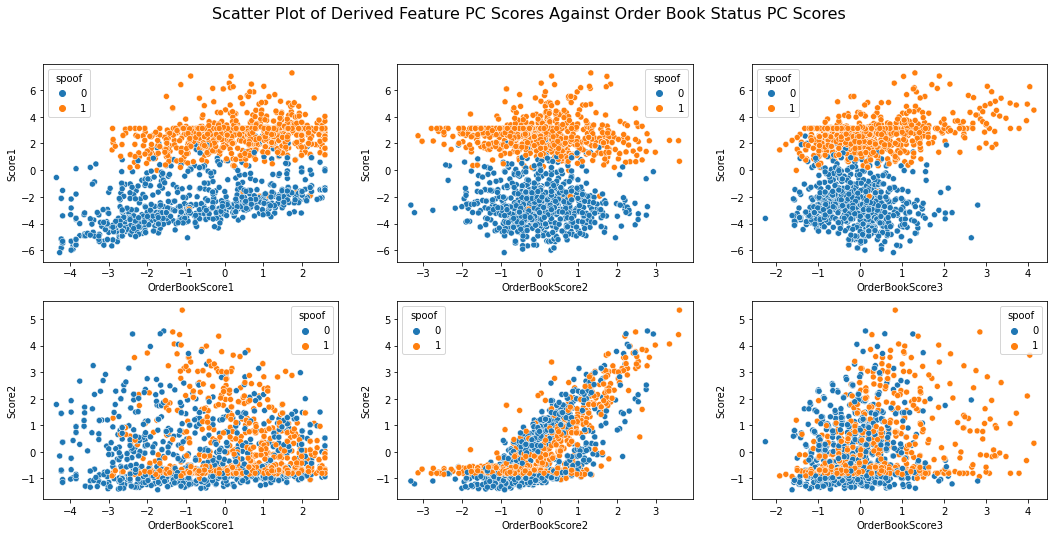

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(18, 8))
for i in range(2):
  for j in range(3):
    sns.scatterplot(y='Score%s'%(i+1), x='OrderBookScore%s'%(j+1), data=fulldata, ax=ax[i][j], hue='spoof')

plt.suptitle('Scatter Plot of Derived Feature PC Scores Against Order Book Status PC Scores', fontsize=16)
plt.show()

### **```Score1``` v. ```OrderBookScore1``` and ```price_level```**


Here we break the ```Score1```-```OrderBookScore1``` scatter plot into 4 by price levels. We also fit a nonparameter smooth to each and see that ```Score1``` increases as ```OrderBookScore1``` at all price levels. 


The most important finding is from ```price_level=2```. At other levels, the prediction is pretty much dominated by ```price_level``` (e.g., at level 4 almost all observations are nonspoofing). At level 2, however, ```price_level``` alone is not enough and some other information needs to come in. The ```price_level=2``` scatter plot indicates that ```OrderBookScore1``` brings in extra information: At this level an observation with larger ```OrderBookScore1``` is more likely to be spoofing. This behavior seems to be picked up by the neural network and embedded in ```Score1```. 


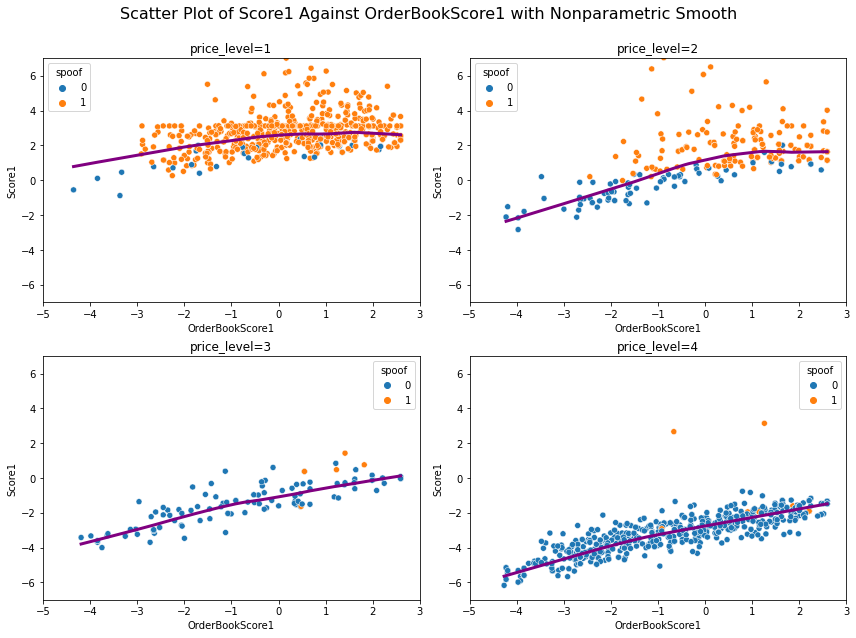

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))

for i, ax in enumerate(axs.flatten()):
  df = fulldata[fulldata['price_level']==i+1]
  lowout = sm.nonparametric.lowess(endog=df['Score1'], exog=df['OrderBookScore1'], frac=0.5)
  sns.scatterplot(y='Score1', x='OrderBookScore1', data=df, ax=ax, hue='spoof')
  DataFrame(lowout, columns=['OrderBookScore1', '']).set_index('OrderBookScore1').plot(ax=ax, style='purple', legend=None, lw=3)
  ax.set(xlim=(-5, 3), ylim=(-7, 7), title='price_level=%s'%(i+1))

plt.suptitle('Scatter Plot of Score1 Against OrderBookScore1 with Nonparametric Smooth', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### **```Score2``` v. ```OrderBookScore2```**

Although we have seen in Task 5 that ```Score1``` is much more informative than ```Score2``` for spoofing prediction, it is still interesting to see that the information of ```OrderBookScore2``` is embedded in ```Score2``` by the neural network. 

Below is a scatter plot of ```Score2``` against ```OrderBookScore2``` and a nonparametric smooth. There is a clear pattern that ```Score2``` increases as ```OrderBookScore2```. 

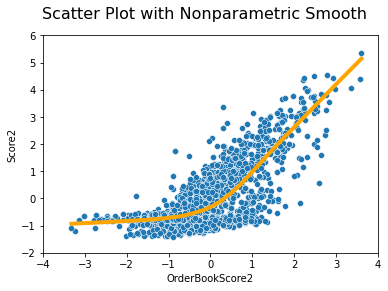

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

lowout = sm.nonparametric.lowess(endog=fulldata['Score2'], exog=fulldata['OrderBookScore2'], frac=0.5)
sns.scatterplot(y='Score2', x='OrderBookScore2', data=fulldata, ax=ax)
DataFrame(lowout, columns=['OrderBookScore2', '']).set_index('OrderBookScore2').plot(ax=ax, legend=None, lw=4, style='orange')
ax.set(xlim=(-4, 4), ylim=(-2, 6))

plt.suptitle('Scatter Plot with Nonparametric Smooth', fontsize=16)
plt.show()

### **```Score1``` and ```Score2``` v. ```side```**

The last interesting pattern is presented below. Again might not be useful for spoofing prediction, but it seems that sell orders (```side=1``` in the data) tend to have lower ```Score2``` than buy orders, and the tendency is even stronger when an observation has higher ```Score1```. The information of ```side``` is embeded in both ```Score1``` and ```Score2``` by the neural network. 

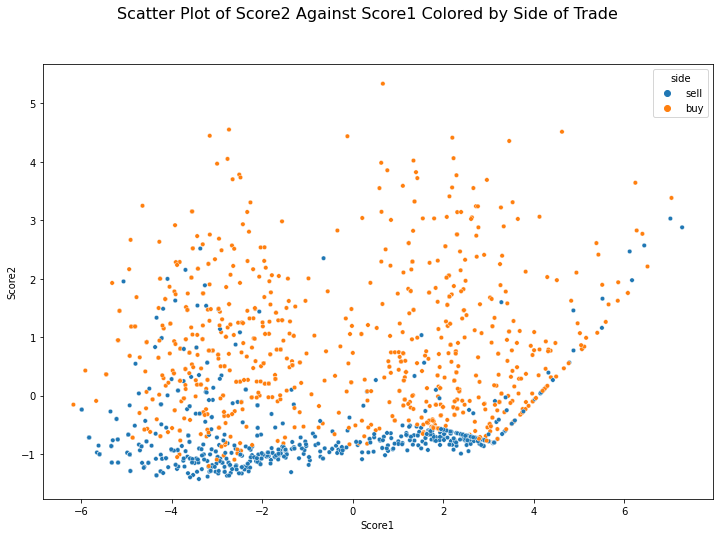

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
df = fulldata[['Score1', 'Score2']].copy()
df['side'] = ['sell' if side==1 else 'buy' for side in fulldata['side']]
sns.scatterplot(x='Score1', y='Score2', data=df, hue='side', s=20, ax=ax)
plt.suptitle('Scatter Plot of Score2 Against Score1 Colored by Side of Trade', fontsize=16)
plt.show()